# Custom CNN architecture

In [1]:
# Run the previous notebook to load all its classes and functions
%run create_dataset_augmentation_rs2.ipynb

Processing calc patients: 100%|█████████████████████████████████████████████████████| 114/114 [00:00<00:00, 151.52it/s]



calc:
  Train patients: 527
  Val patients:   112
  Test patients:  114
  Total patients: 753
  Overlaps: train-val=0, train-test=0, val-test=0
  Image counts -> Train: 1283, Val: 326, Test: 263


Processing mass patients: 100%|█████████████████████████████████████████████████████| 135/135 [00:00<00:00, 364.18it/s]


mass:
  Train patients: 624
  Val patients:   133
  Test patients:  135
  Total patients: 892
  Overlaps: train-val=0, train-test=0, val-test=0
  Image counts -> Train: 1193, Val: 262, Test: 241


# Normal Data augmentation

We will augment **only the training data** :


In [2]:
print(f"X_train_calc size: {X_train_non_clahe_calc.shape}") 
print(f"X_train_mass size: {X_train_non_clahe_mass.shape}")

X_train_calc size: (1283, 224, 224, 1)
X_train_mass size: (1193, 224, 224, 1)


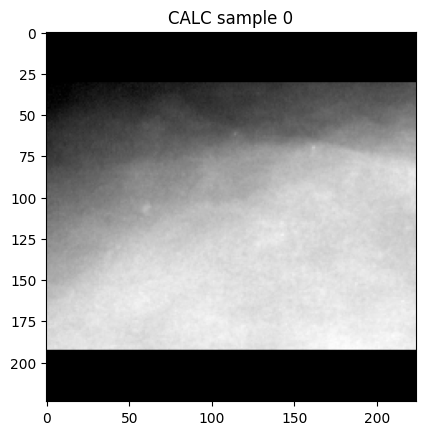

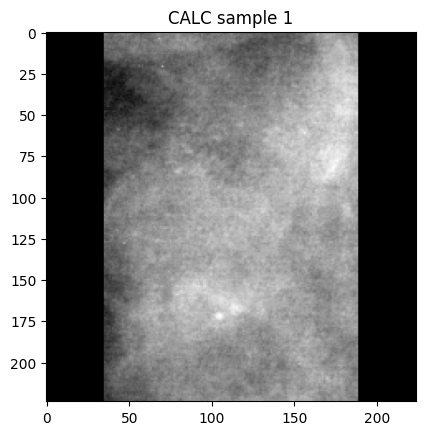

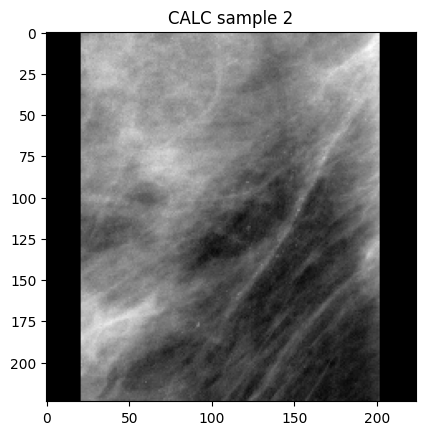

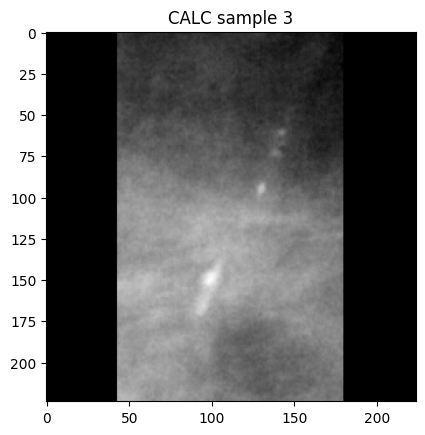

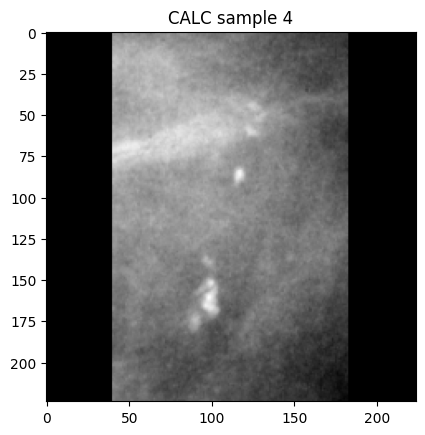

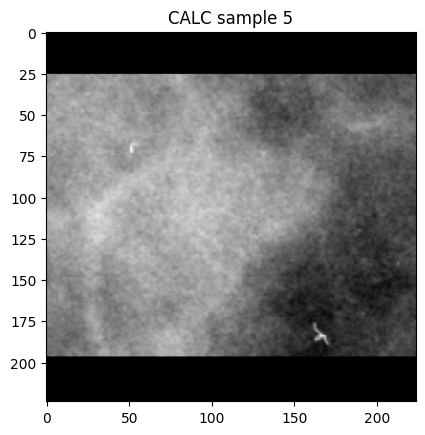

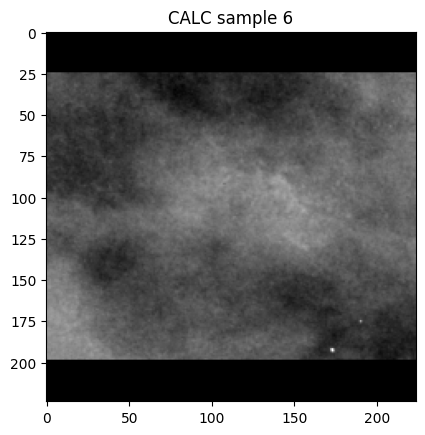

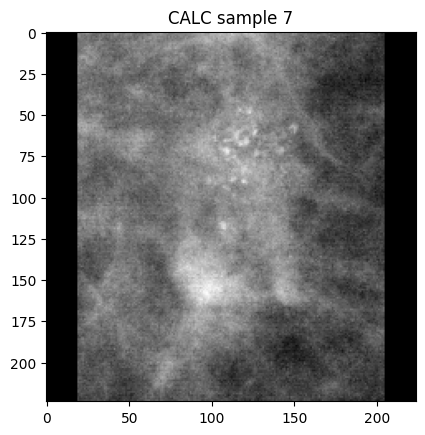

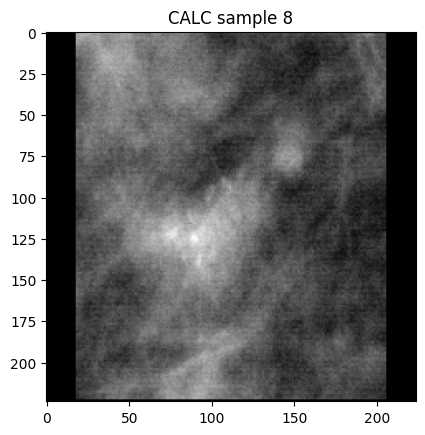

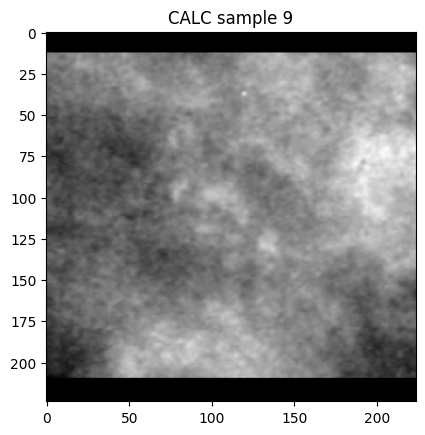

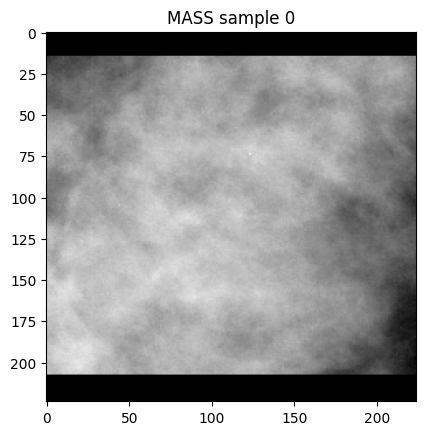

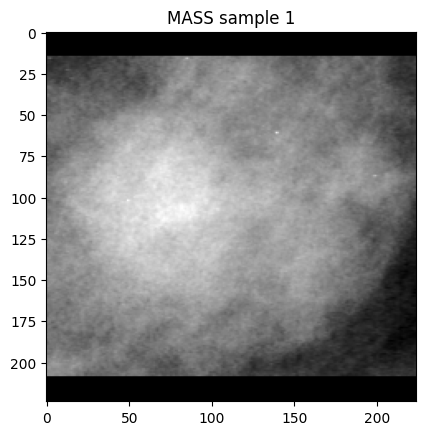

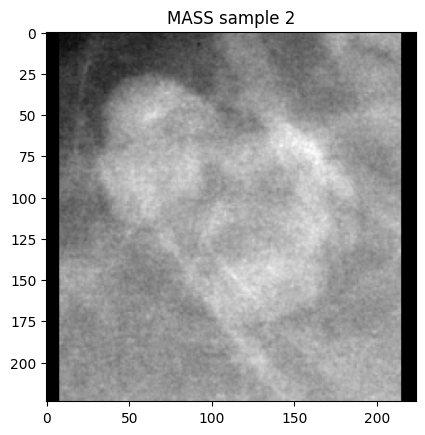

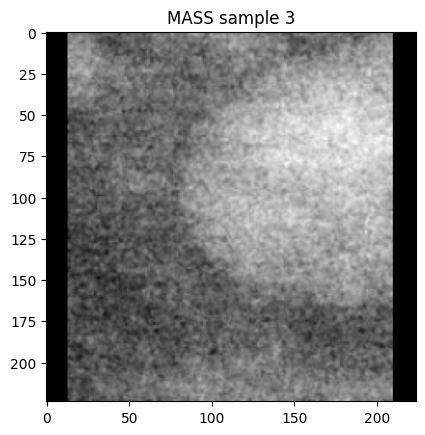

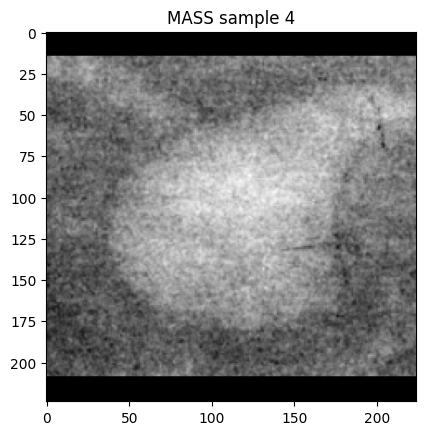

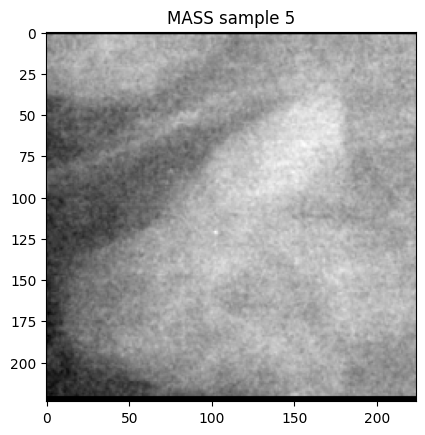

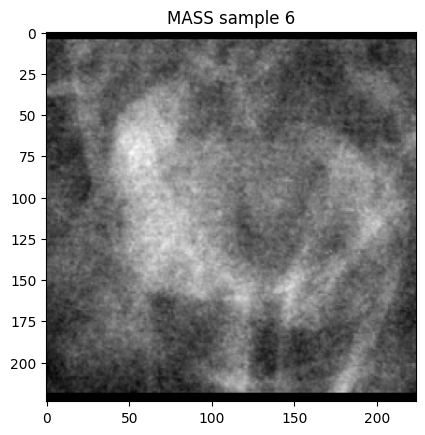

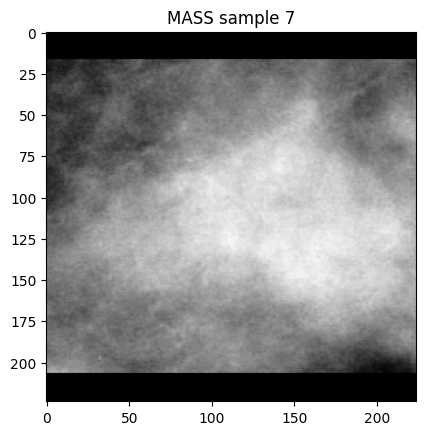

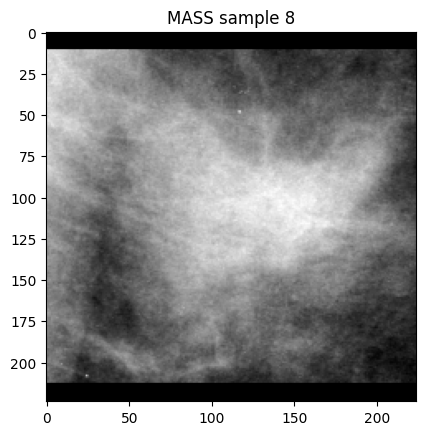

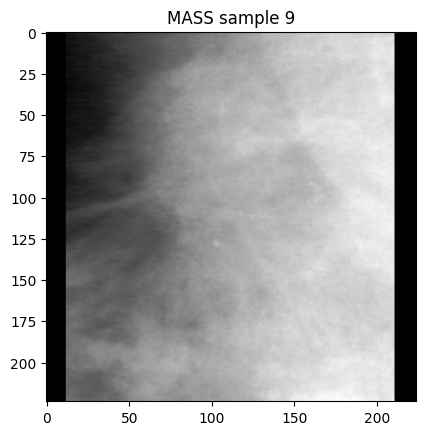

In [3]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.imshow(X_train_non_clahe_calc[i].squeeze(), cmap='gray')
    plt.title(f"CALC sample {i}")
    plt.show()

for i in range(10):
    plt.imshow(X_train_non_clahe_mass[i].squeeze(), cmap='gray')
    plt.title(f"MASS sample {i}")
    plt.show()

In [4]:
from scipy import ndimage

In [5]:
def data_augmentation(X, y, aug_factor=1):
    """
    Apply data augmentation to the training set.

    Augmentations:
    - Horizontal & vertical flipping
    - Rotation (0–90 degrees)
    - Shifting (translation)
    - Scaling (zoom in/out)
    - Gaussian noise injection

    Args:
        X: Training images (N, 224, 224, 1)
        y: Training labels
        aug_factor: Number of augmented samples per image

    Returns:
        Augmented images and labels
    """
    import cv2
    import numpy as np

    h, w = 224, 224
    X_aug, y_aug = [], []

    for img, label in zip(X, y):

        # Keep original
        X_aug.append(img)
        y_aug.append(label)

        img_2d = img.squeeze(-1)

        for _ in range(aug_factor):

            aug_img = img_2d.copy()

            noise = np.random.normal(0, 3, aug_img.shape)
            aug_img = np.clip(aug_img + noise, 0, 255)

            # Restore channel dimension
            aug_img = np.expand_dims(aug_img.astype(np.uint8), axis=-1)

            X_aug.append(aug_img)
            y_aug.append(label)

    return np.array(X_aug), np.array(y_aug)


In [6]:
import numpy as np

# 1. Augment Calcifications (Factor 1 -> Doubles count)
# 1334 * 2 = 2668
X_calc_aug, y_calc_aug = data_augmentation(
    X_train_non_clahe_calc, 
    y_train_non_clahe_calc, 
    aug_factor=1
)

# 2. Augment Masses (Factor 2 -> Triples count to ensure we overshoot Calc)
# 1188 * 3 = 3564
X_mass_aug, y_mass_aug = data_augmentation(
    X_train_non_clahe_mass, 
    y_train_non_clahe_mass, 
    aug_factor=2
)

# 3. Balancing: Find the target size (the size of the Calc set)
target_size = len(X_calc_aug)

# Optional: Shuffle Mass data before trimming to ensure randomness
# (indices are created to shuffle X and y in unison)
indices = np.arange(len(X_mass_aug))
np.random.shuffle(indices)
X_mass_aug = X_mass_aug[indices]
y_mass_aug = y_mass_aug[indices]

# 4. Trim Mass dataset to match Calc dataset exactly
X_mass_final = X_mass_aug[:target_size]
y_mass_final = y_mass_aug[:target_size]

# Calc is already at target size, but rename for consistency
X_calc_final = X_calc_aug
y_calc_final = y_calc_aug

# --- Verification ---
print(f"Final CALC count: {len(X_calc_final)}")
print(f"Final MASS count: {len(X_mass_final)}")
print(f"Ratio: {len(X_calc_final) / (len(X_calc_final) + len(X_mass_final)):.1%} Calc / {len(X_mass_final) / (len(X_calc_final) + len(X_mass_final)):.1%} Mass")

Final CALC count: 2566
Final MASS count: 2566
Ratio: 50.0% Calc / 50.0% Mass


In [7]:
X_train_aug = np.concatenate([X_calc_final, X_mass_final], axis=0)
y_train_aug = np.concatenate([y_calc_final, y_mass_final], axis=0)

# shuffling for better convergence
train_indices = np.arange(len(X_train_aug))
np.random.shuffle(train_indices)

X_train_aug = X_train_aug[train_indices]
y_train_aug = y_train_aug[train_indices]

X_val = np.concatenate([X_val_non_clahe_calc, X_val_non_clahe_mass], axis=0)
y_val = np.concatenate([y_val_non_clahe_calc, y_val_non_clahe_mass], axis=0)

X_test = np.concatenate([X_test_calc, X_test_mass], axis=0)
y_test = np.concatenate([y_test_calc, y_test_mass], axis=0)


print(f"Final shapes AFTER AUGMENTATION & SHUFFLE:")
print(f"X_train_aug: {X_train_aug.shape}")
print(f"X_val:       {X_val.shape}")
print(f"X_test:      {X_test.shape}")

Final shapes AFTER AUGMENTATION & SHUFFLE:
X_train_aug: (5132, 224, 224, 1)
X_val:       (588, 224, 224, 1)
X_test:      (504, 224, 224, 1)


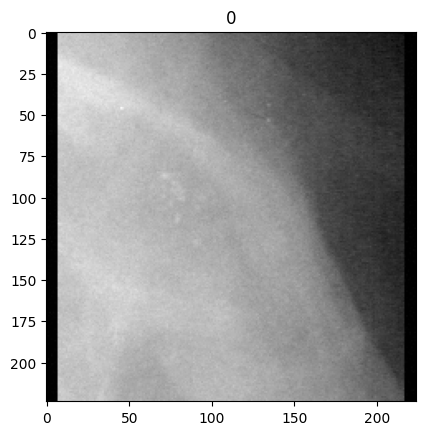

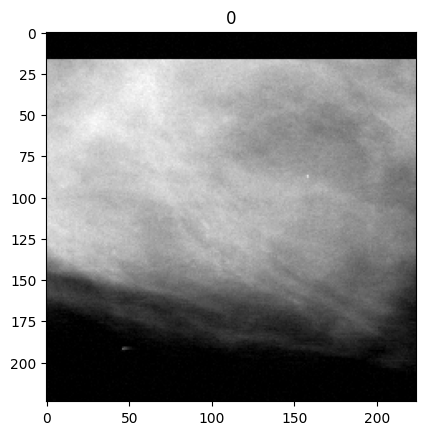

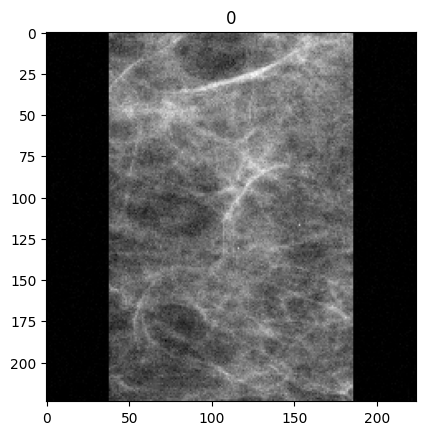

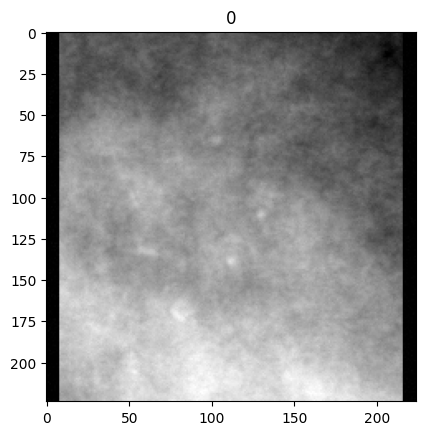

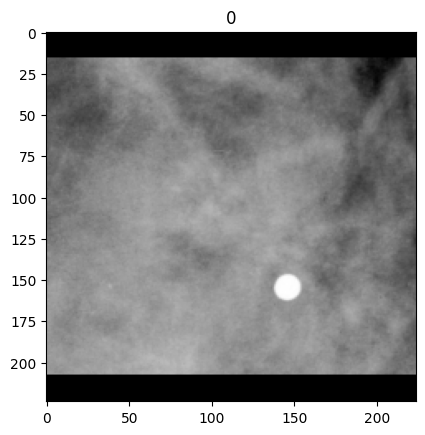

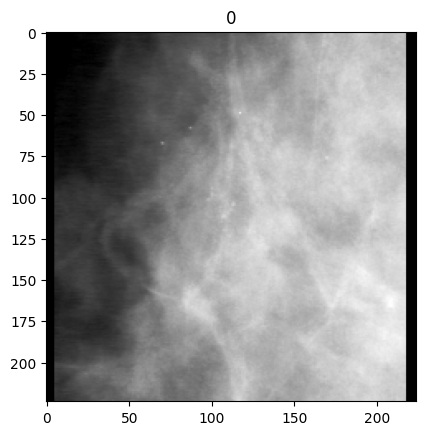

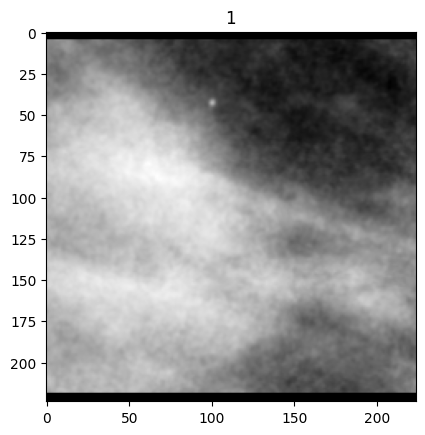

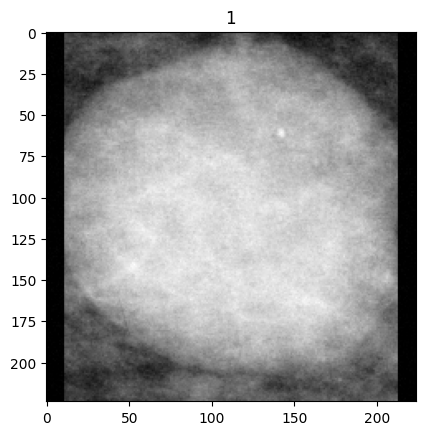

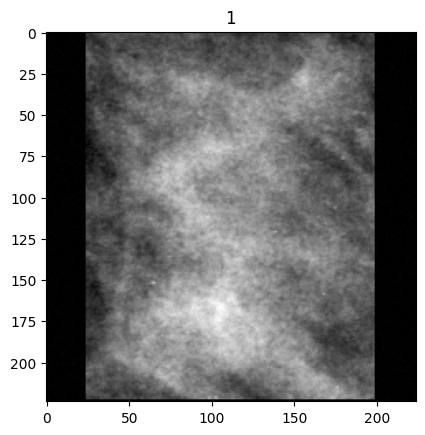

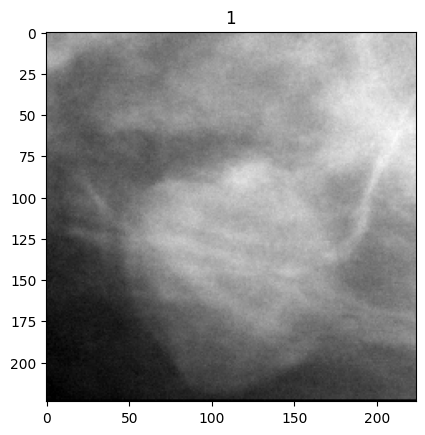

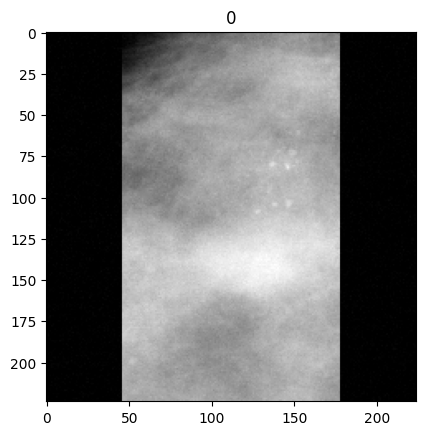

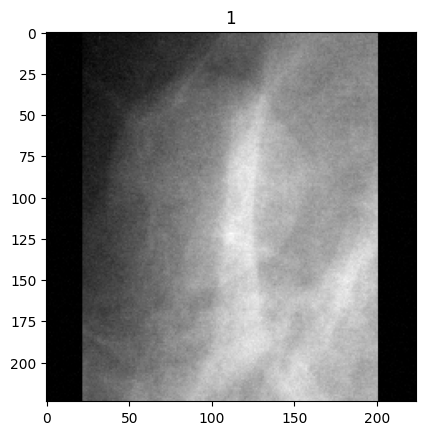

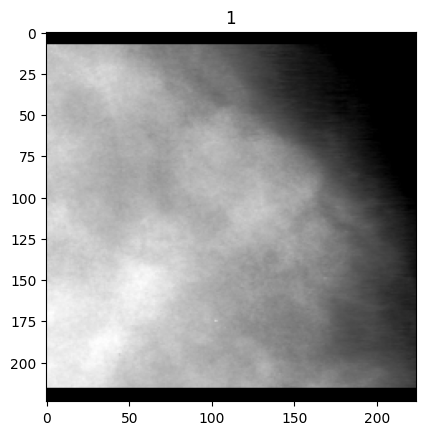

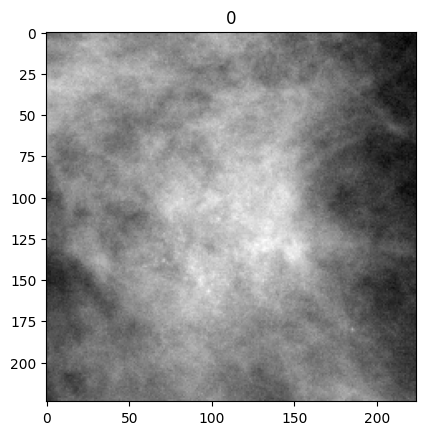

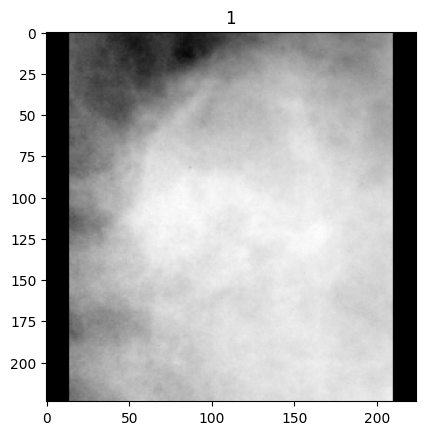

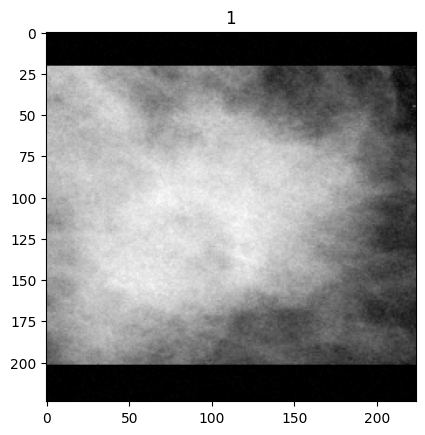

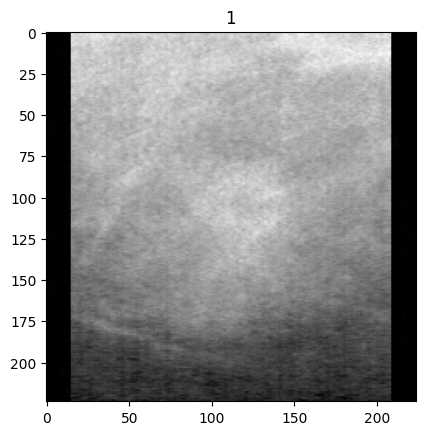

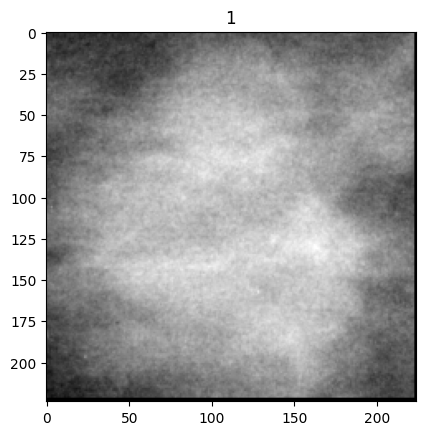

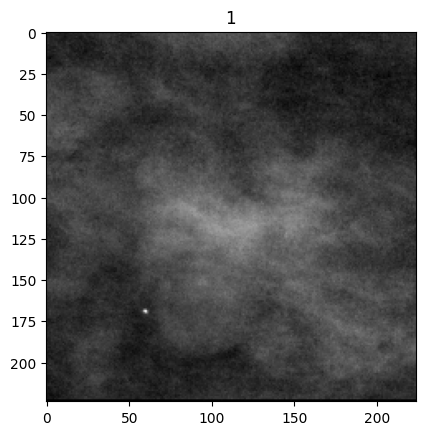

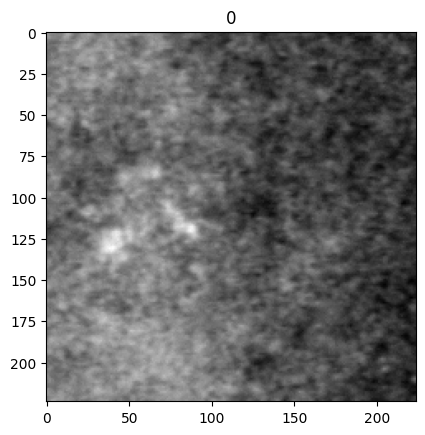

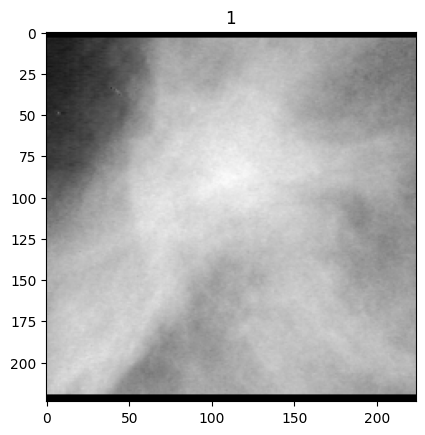

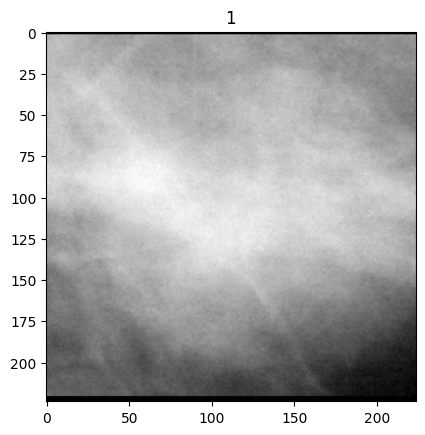

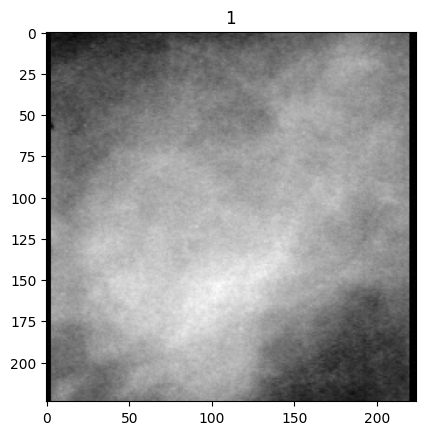

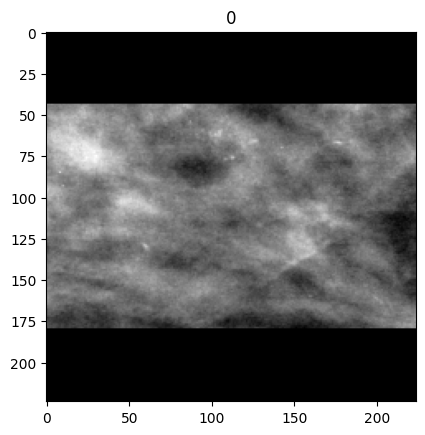

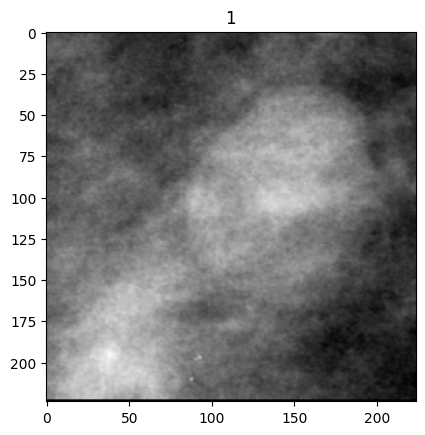

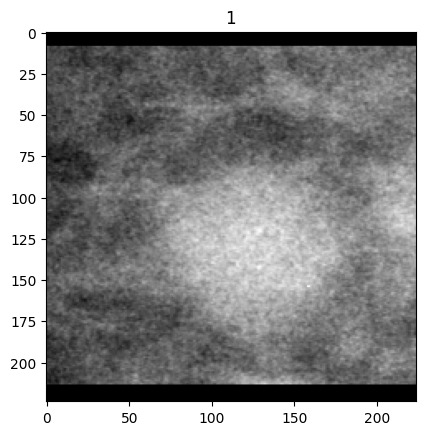

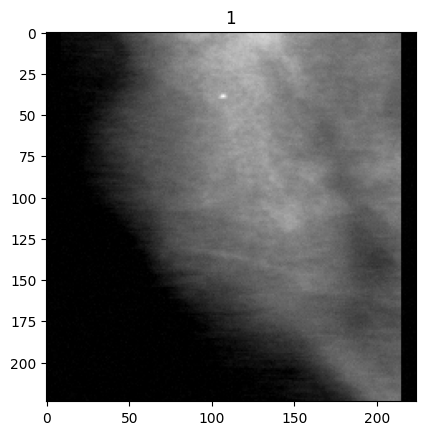

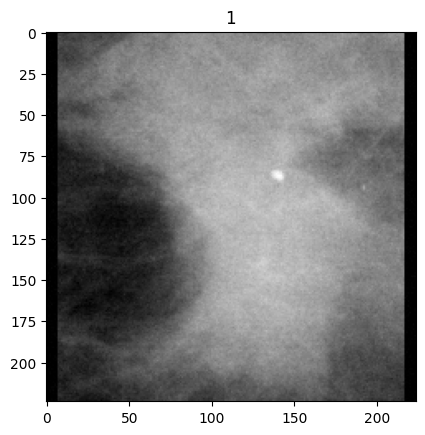

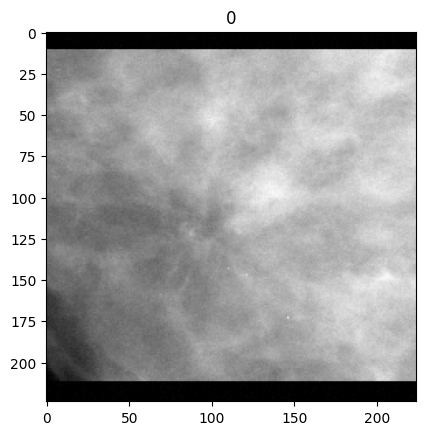

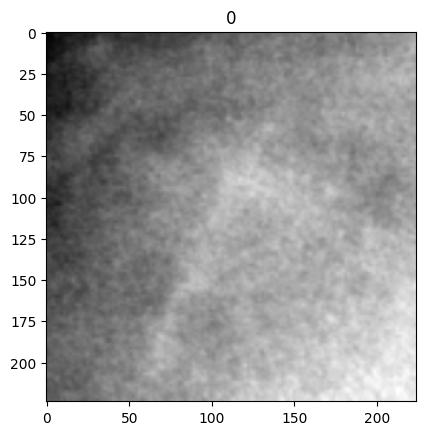

In [8]:
import matplotlib.pyplot as plt
for i in range(30):
    plt.imshow(X_train_aug[i].squeeze(), cmap='gray')
    plt.title(y_train_aug[i])
    plt.show()

### Normalize Data
This step is important because:
- we have features which are in a wide range (each pixels ranges from 0 to 255)
- we have to make them matter the same to the ML model
- prevent numerical instability
- normal distribution assumption

In [9]:
X_train_aug = X_train_aug.astype('float32') / 255.0
X_val   = X_val.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0


In [10]:
print(f"Final shapes AFTER AUGMENTATION & NORMALIZATION -> X_train_aug: {X_train_aug.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

Final shapes AFTER AUGMENTATION & NORMALIZATION -> X_train_aug: (5132, 224, 224, 1), X_val: (588, 224, 224, 1), X_test: (504, 224, 224, 1)


# B. Training CNNs WITH AUGMENTATION 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LeakyReLU, BatchNormalization, Conv2D, MaxPooling2D, Flatten,  Dropout, Activation
from tensorflow.keras.utils import plot_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import tensorflow as tf
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import seaborn as sns
import time

## Explaining some concepts that we will use later

### CNNs
- specialized NNs designed for grid-like data
- automatically learn spacial hierarchies of features through convolution operations
- highly effective in tasks involving visual perception

### Convolutional layer
**Convolution** is a mathematical operation where a small filter (kernel) is systematically applied across an input (such as an image) to produce a feature map that captures important local patterns like edges, textures, or more complex structures.

- **number of filters** = how many different kernels does the layer apply? So we basically get **number of filters** different feature maps.
- As we go on through the layers of the model, we may need more and more different kernels to try, because we have more intricate patterns in the images.

- **kernel_size** = what is the size of the filter/kernels, helping us to detect edges like shapes, edges etc.

- **activation** = the activation function used

### Pooling layers

A pooling layer reduces the spatial dimentions(width and height) of a feature map by summarizing regions of th input, helping to decrease computation, control overfitting, and make the network more robust to small translations

Purpose:

- downsampling: reduces the size of feature maps;
- feature preservation: keeps the most important information
- translation invariance: small changes in input data do not change the pooled output much

### Max Pooling

Helps us detect the strongest activation, e.g. what feature is the most present. This way, we can detect more proeminent patterns and also improve computations.

### Fully Connected Layers

Learn from the high-level features extracted by convolutional and pooling layers

- **dropout** - during training, turns off a percent of neurons in the Dense layer, to prevent overfitting.

### ReLU Activation
- keeps patterns of the data, also getting rid of negative values
- neurons stuck with negative inputs stop updating (gradient = 0)
- most popular in modern NNs

### LeakyReLU 
- allows a small gradient when x < 0 → avoids dying ReLU.

### Batch size
- how many training samples the network processes before updating its weights during training. It influences both the model's performance and the computational efficiency.
- some mostly used values are 32, 64, 128 ...
- I chose 32 because it puts in balance the computational resources needed and the efficiency of the model



### Adam Optimizer

Adam (short for **Adaptive Moment Estimation**) is one of the most popular and effective optimization algorithms used to train deep learning models. Adam adapts the learning rate for each parameter individually using **first** and **second moments** of the gradients:

- The **first moment** is the **mean** of the gradient (like momentum).
- The **second moment** is the **uncentered variance** of the gradient.

This helps Adam:
- Converge faster
- Handle sparse gradients
  

# Custom CNNs

In [12]:
#Apply early stopping to save time & avoid overfitting
# Early stopping
early_stop = EarlyStopping(patience=8, restore_best_weights=True,monitor='val_loss', verbose=1)


    # Model definition
model = Sequential([
        Input(shape=(224, 224, 1)),
        Conv2D(32, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(32*2, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Conv2D(32*4, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    # Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

    # Train
model.fit(
        X_train_aug, y_train_aug,
        validation_data=(X_val, y_val),
        epochs=60,
        batch_size=8,
        callbacks=[early_stop]
    )



Epoch 1/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 129s 199ms/step - accuracy: 0.6962 - loss: 0.5767 - val_accuracy: 0.7330 - val_loss: 0.5189
Epoch 2/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 125s 194ms/step - accuracy: 0.7804 - loss: 0.4743 - val_accuracy: 0.8299 - val_loss: 0.4092
Epoch 3/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 125s 195ms/step - accuracy: 0.8102 - loss: 0.4261 - val_accuracy: 0.8265 - val_loss: 0.3888
Epoch 4/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 126s 196ms/step - accuracy: 0.8293 - loss: 0.3721 - val_accuracy: 0.8418 - val_loss: 0.3771
Epoch 5/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 125s 194ms/step - accuracy: 0.8615 - loss: 0.3202 - val_accuracy: 0.8571 - val_loss: 0.3679
Epoch 6/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 126s 196ms/step - accuracy: 0.8858 - loss: 0.2554 - val_accuracy: 0.8350 - val_loss: 0.4039
Epoch 7/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 125s 195ms/step - accuracy: 0.9078 - loss: 0.2139 - val_accuracy: 0.8384 - val_loss: 0.4850
Epoch 8/60
642/642 ━━━━━━━━━━━━━━━━━━━━ 125s 194ms/step - accuracy: 0.9250 -

# Other metrics

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step

Classification Report:
sequential
              precision    recall  f1-score   support

           0     0.8517    0.8988    0.8746       326
           1     0.8648    0.8053    0.8340       262

    accuracy                         0.8571       588
   macro avg     0.8582    0.8521    0.8543       588
weighted avg     0.8575    0.8571    0.8565       588

F2-score: 0.8567


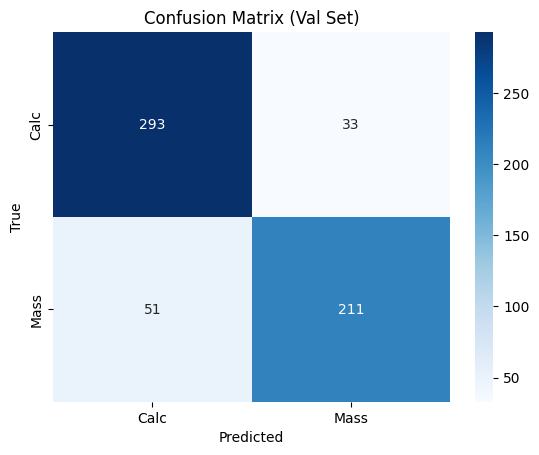

In [13]:
from sklearn.metrics import fbeta_score


# Predict probabilities
y_val_probs = model.predict(X_val)

# Convert probabilities to class labels
y_val_pred = (y_val_probs >= 0.5).astype(int).flatten()

# Classification Report (includes precision, recall, f1-score per class)
print("\nClassification Report:")
print(model.name)
print(classification_report(y_val, y_val_pred, digits=4))


f2_score = fbeta_score(y_val, y_val_pred, beta=2, average='weighted')
print("F2-score:", round(f2_score, 4))


cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Calc', 'Mass'], yticklabels=['Calc', 'Mass'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Val Set)')
plt.show()

